# Visualisation in Python

So far, we've been mostly been dealing with databases, how to manipulate data, and so on. But sometimes it's easier to visualise the data to check for statistical errors (like outliers), normalisation (are the scales in the same region) which improves model accuracy and performance, and inference (what relationship can we deduce from the variables).

In python, visualisation can be done in a lot of libraries such as plotly, but the most common one is matplotlib.

In [10]:
%%capture
!pip install matplotlib
import matplotlib.pyplot as plt

matplotlib is a python library that gives objects we can use to store data and represent them as graphs. The matplotlib object hierarchy looks something like this:

<img src="./images/figure.jpg">

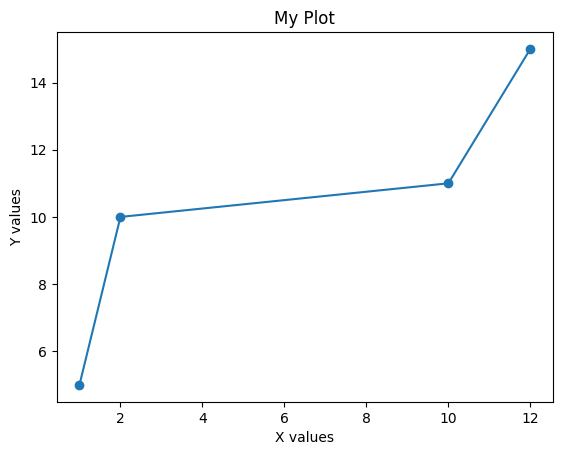

In [11]:
# Example

X_values = [1, 2, 10, 12]
Y_values = [5, 10, 11, 15]

fig, ax = plt.subplots() # creates a figure with one ax object

ax.set_title("My Plot") # creates a title artist called my plot 
ax.set_xlabel("X values") # creates a xlabel artist called X values
ax.set_ylabel("Y values") # creates a ylabel artist called Y values
ax.plot(X_values, Y_values) # creates a Line2d artist
ax.scatter(X_values, Y_values) # creates a PathCollection artist

plt.plot makes straight lines, while plt.scatter makes dotted lines. We can customize each artist as below:

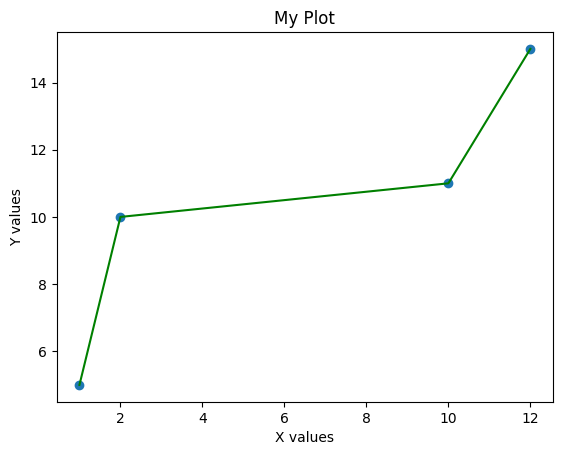

In [12]:
myline = ax.lines
myline[0].set_color("green") # access the first line since we only have one line

display(fig)

We can draw multiple artists in a plot as shown in the previous slides, here are some more examples:

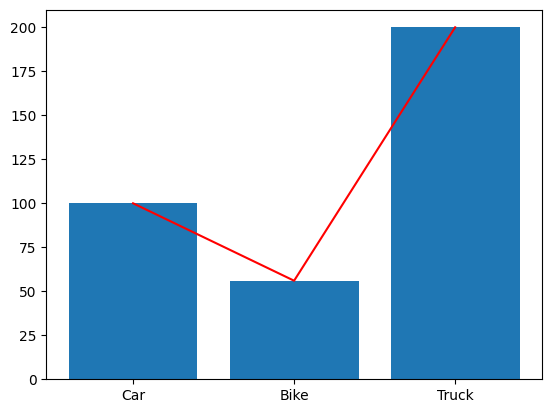

In [13]:
ax.cla() # removes artists from the axes but keep axes

X_values = ["Car", "Bike", "Truck"]
Y_values = [100, 56, 200]

X_line = [0, 1, 2]
Y_line = [100, 56, 200]

ax.bar(X_values, Y_values, zorder=1) # low zorder means its drawn first (back)
ax.plot(X_line, Y_line, color="red", zorder=2) # high zorder means its drawn later (front)

display(fig) # this command re-renders and displays our figure

Let's say you want to change the labels for x axis, and change the range for y axis, you can easily do so using:

/tmp/ipykernel_9856/4163662066.py:1: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["sedan", "roadbike", "container"])


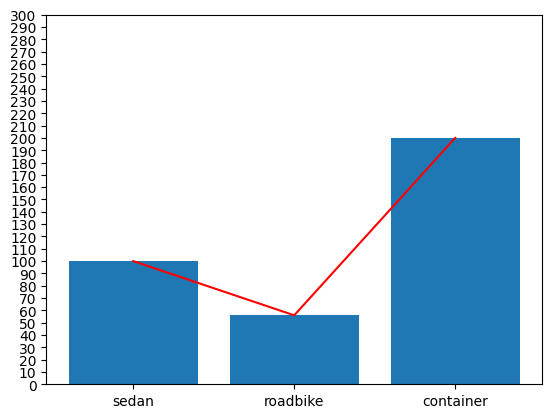

In [14]:
ax.set_xticklabels(["sedan", "roadbike", "container"])
ax.set_yticks(range(0, 310, 10))

display(fig)

Finally, if we want to label the artists themselves we can do so using

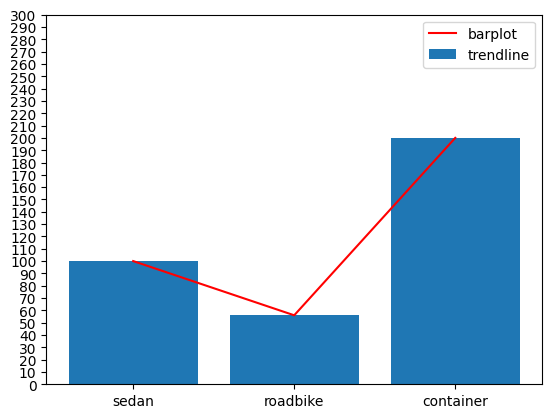

In [15]:
ax.legend(["barplot", "trendline"]) # in the order of creation

display(fig)

#### Multiple Plots

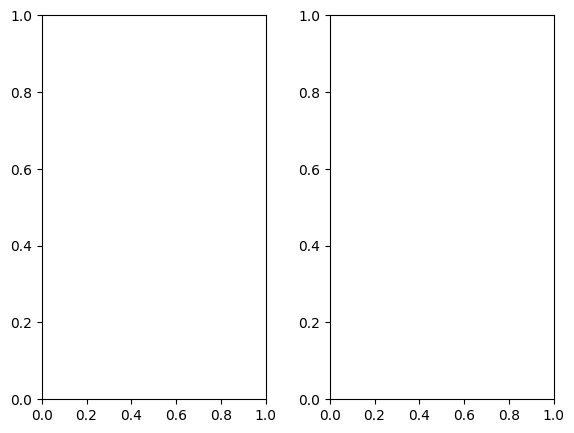

In [16]:
fig.clf() # Removes all axes in a figure

fig.add_axes([0.1, 0.1, 0.35, 0.8])
fig.add_axes([0.55, 0.1, 0.35, 0.8])

# add axes is coordinate system between 0-1
#[distance from left, bottom, width, height]

display(fig)

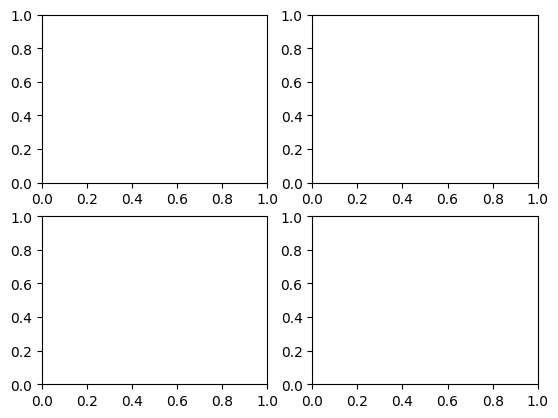

In [17]:
# easier way of doing it:

fig2, axs = plt.subplots(2, 2) # 2 rows and 2 column

we can do everything as usual:

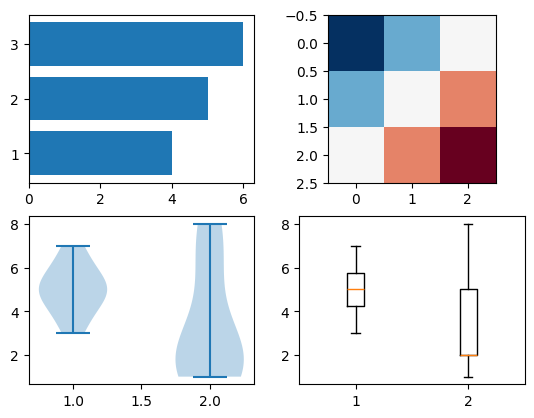

In [18]:
axs[0, 0].barh([1, 2, 3], [4, 5, 6])
axs[0, 1].imshow([[6, 4, 2], [4, 2, 0], [2, 0, -2]], cmap="RdBu")
axs[1, 0].violinplot([[5, 5, 5, 5, 4, 4, 3, 6, 6, 7], [1, 1, 2, 2, 2, 2, 5, 8, 7]], positions=[1, 2])
axs[1, 1].boxplot([[5, 5, 5, 5, 4, 4, 3, 6, 6, 7], [1, 1, 2, 2, 2, 2, 5, 8, 7]], positions=[1, 2])

display(fig2)

# Introduction to Machine Learning

What is machine learning? It's a buzzword that's been used everywhere especially in this modern era. Machine learning is essentially trying to learn a mapping that can generalise well given data. Here's a nice example:

Suppose we are baking a cake.

Say we have 5 recipes:

2 eggs + 1 flour + 0.5 water + 1 sugar = 7.5

2.5 eggs + 2 flour + 1 water + 2 sugar = 8.2

A machine learning algorithm learns the relationship between these two and create mapping f() that take eggs, flour, water and sugar as input and gives estimated rating. It learns this by using training data (as shown above in the 5 recipes).

For example, if we wanna see what the taste looks like for 3 eggs, 2.5 flour, 0.75 water and 3 sugar we can do f(3, 2.5, 0.75, 3) = ?. And a trained algorithm will be able to predict the rating. The problem above is called a regression problem

<img src="./images/ML.png">

# Regression

The general regression model is given by:

$$g(\mathbb{E}(Y_i)) = \beta_0 + \sum_{j=1}^p f_j(X_{ij}) + Z_i b + \lambda h(\beta)$$

This looks really scary, but don't worry. This is the absolute general version of "regression" (Generalised Additive Mixed Model) but in industry practice we usually deal with simpler versions. The simplest version being "Ordinary Least Squares" which is given by:

$$Y_i = \beta_0 + \sum_{j=1}^p \beta_j X_{ij} $$

For those of you who can't read math. This is basically saying the output Y is equal to adding up the intercept $\beta_0$ which really is just a vertical offset (if ratings start at 50 then we set intercept to be bigger or equal to 50). And we also add up weighted coefficients of each feature. This tells us how strong each feature contributes to the final output Y. And these coefficients doesn't change. And can be used to predict new outputs.

Linear regression then tries to learn $\beta_0, \beta_j$ given some data. Hence trying to "fit the line" into the data.

In [19]:
# To implement this in python we use the library called scikit-learn
!pip install scikit-learn
import sklearn as sk


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [20]:
import numpy as np

X = np.array([1, 2, 3, 4, 5])
Y = np.array([10, 20, 60, 70, 90])

X = X.reshape(-1, 1)

model = sk.linear_model.LinearRegression()
model.fit(X, Y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
# Testing

model.predict([[2]]) # why is this off by 9 points?

array([29.])

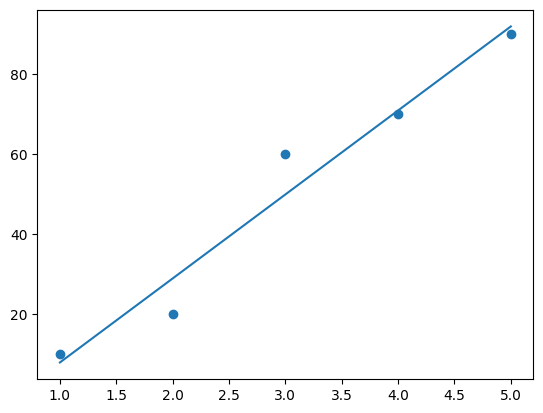

In [28]:
y_pred = model.predict(X)
y_pred = y_pred.reshape(-1, 1)

plt.scatter(X, Y) # a quick way to do plotting
plt.plot(X, y_pred)

### Evaluation Criteria

machine learning is useless if we have no way of evaluating how good it actually is. Sure, we can use plotting to see how good it fits, but sometimes we want to automate model selection (such as AutoML) and they require numbers to figure out how good a model performs compare to the others. Sometimes machine learning models have hyperparameters (essentially parameters that we have to set, and not parameters that they try to learn).

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(Y, y_pred)
mse = mean_squared_error(Y, y_pred)
r2 = r2_score(Y, y_pred)

print(mae, mse, r2)

4.800000000000001 37.999999999999986 0.9586956521739131


mean absolute error shows how much actual euclidean (normal) distance combined does each point differ by its prediction

mean squared error is similar to mean absolute error but it uses the distance squared instead, this effectively penalizes larger deviations.

r2 score shows how good does the model explain the sample variance (ratio of variances between predicted and true values). If it's 1 then the model fully explains the variance. If it's 0 then it's the same as predicting the mean. If it's negative then it's worse than predicting the mean. It gives a more percentage (0-1) expression of how good your model fits the data.

## Classification